# Using Bifurcations to Switch Between Point Attractors and Limit Cycles

**Course project based on:**  
Farshad Khadivar, Ilaria Lauzana, and Aude Billard,  
*Learning Dynamical Systems with Bifurcations*, Robotics and Autonomous Systems.

This project studies how a single nonlinear dynamical system can be used to generate both point-to-point and rhythmic robot motion. The selected paper provides a practical robotics application of several concepts covered in the course, including equilibrium points, stability, phase portraits, limit cycles, bifurcations, and switching behavior in dynamical systems.

The central question addressed in this project is:

> **Can one dynamical system transition from a stable point attractor to a stable limit cycle by varying only one interpretable parameter?**

This question is relevant in robotics because many manipulation tasks naturally involve both discrete and periodic phases. For example, a robot may first move toward an object and then perform a repeated motion such as wiping or polishing. A direct approach would be to use one controller for reaching and another controller for rhythmic motion. However, switching between two independently defined dynamical systems can introduce abrupt changes in velocity and may lead to jerky or unstable transient behavior.

The paper addresses this issue by embedding both behaviors within a single parameterized dynamical system. By varying a bifurcation-like parameter, the same system can smoothly transition between a stable point attractor and a stable limit cycle, avoiding the need for hard switching between separate controllers.

In this project, we focus on replicating the core nonlinear-dynamics mechanism and interpreting it in a robotics context. First, we analyze a simplified two-dimensional dynamical system using stability analysis, phase portraits, parameter sweeps, and a comparison between hard switching and smooth parameter variation. We then extend the analysis to a robotic simulation study in MuJoCo using the Franka Research 3 robot, where the dynamical system is used to generate reference end-effector motion.

## 1. Motivation

Robotic motion often contains two different behaviors:

- **Point-to-point motion:** reaching, moving to a target, pick-and-place.
- **Rhythmic motion:** wiping, polishing, walking, drumming.

A common approach is to model these with separate dynamical systems and switch between them online. The paper argues that hard switching can create discontinuities, jerky velocity profiles, and possible instability when the systems have different attractors. The proposed solution is to encode both behaviors in one parameterized dynamical system, so changing a parameter changes the behavior without replacing the controller.

### 1.1 Course Concepts Used in This Project

Before implementing the selected model, we first identify the nonlinear-dynamics concepts from the course that appear in the paper. The paper is particularly relevant because it connects abstract concepts from nonlinear dynamical systems to a concrete robotics application.

The main course concepts used in this project are:

1. **Equilibrium point:** when the target radius is zero, the system behaves as a stable point attractor.
2. **Stability:** the radial error decays with time, which allows the model to be interpreted using asymptotic stability.
3. **Phase portrait:** trajectories starting from different initial conditions are used to visualize the vector field and the global attraction behavior.
4. **Limit cycle:** when the target radius is nonzero, the trajectory does not converge to a fixed point; instead, it converges to a closed orbit.
5. **Bifurcation:** changing the radius parameter changes the qualitative long-term behavior of the system from point convergence to periodic motion.
6. **Switched systems:** the paper motivates why switching between independently defined dynamical systems can produce abrupt transients and jerky motion.
7. **System identification:** the full paper also includes learning model parameters from demonstration data, although the present project focuses mainly on the nonlinear-dynamics mechanism and its simulation-level robotic interpretation.

Thus, the paper is not treated only as a robot-control paper. In this project, it is used as a case study showing how nonlinear dynamical-system concepts can be used to design interpretable robot-motion generators.

## 2. Classical Hopf Bifurcation and Paper Formulation

### 2.1 Connection to the Classical Hopf Bifurcation

A standard supercritical Hopf bifurcation can be written in polar coordinates as

$$
\dot{r} = \mu r - r^3, \qquad \dot{\theta}=\omega.
$$

For this classical Hopf normal form:

- If `mu < 0`, the origin `r=0` is stable.
- If `mu > 0`, a stable limit cycle appears at `r = sqrt(mu)`.

This is the class concept of a **Hopf bifurcation**: changing a bifurcation parameter changes the qualitative long-term behavior from an equilibrium to a periodic orbit.

The paper does not directly use the classical Hopf normal form. Instead, it designs a Hopf-inspired system where the target radius `rho0` directly controls whether the system behaves as a point attractor or a limit cycle. This makes the controller easier to modulate in robotics, because the cycle radius, center, orientation, and rotation speed can be changed explicitly.

### 2.2 Numerical Comparison with the Classical Hopf Normal Form

To make the theoretical connection clearer, we first simulate the classical Hopf normal form before studying the modified dynamical system used in the paper. The classical supercritical Hopf normal form in polar coordinates is

$$
\dot{r} = \mu r - r^3, \qquad \dot{\theta} = \omega .
$$

The qualitative behavior of this system depends on the parameter $\mu$:

- For $\mu < 0$, the origin is a stable equilibrium point.
- For $\mu = 0$, the system is at the transition value.
- For $\mu > 0$, the origin loses stability and a stable limit cycle appears with radius

$$
r^* = \sqrt{\mu}.
$$

Thus, changing the parameter $\mu$ changes the long-term behavior of the phase portrait from convergence to a point to convergence to a closed orbit.

The paper uses a related idea but modifies the parameterization to make it more suitable for robot motion generation. Instead of using $\mu$ as the main control parameter, the paper introduces the target radius $\rho_0$. In this formulation, the final orbit radius is directly controlled as

$$
\rho^* = \rho_0 .
$$

This distinction is important from a robotics perspective. In the classical Hopf normal form, the limit-cycle radius depends on $\sqrt{\mu}$, whereas in the paper’s formulation the desired radius can be specified directly through $\rho_0$. Therefore, the classical model is useful for understanding the qualitative transition between fixed-point and cyclic behavior, while the paper’s model provides a more interpretable parameterization for commanding robot motion.

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


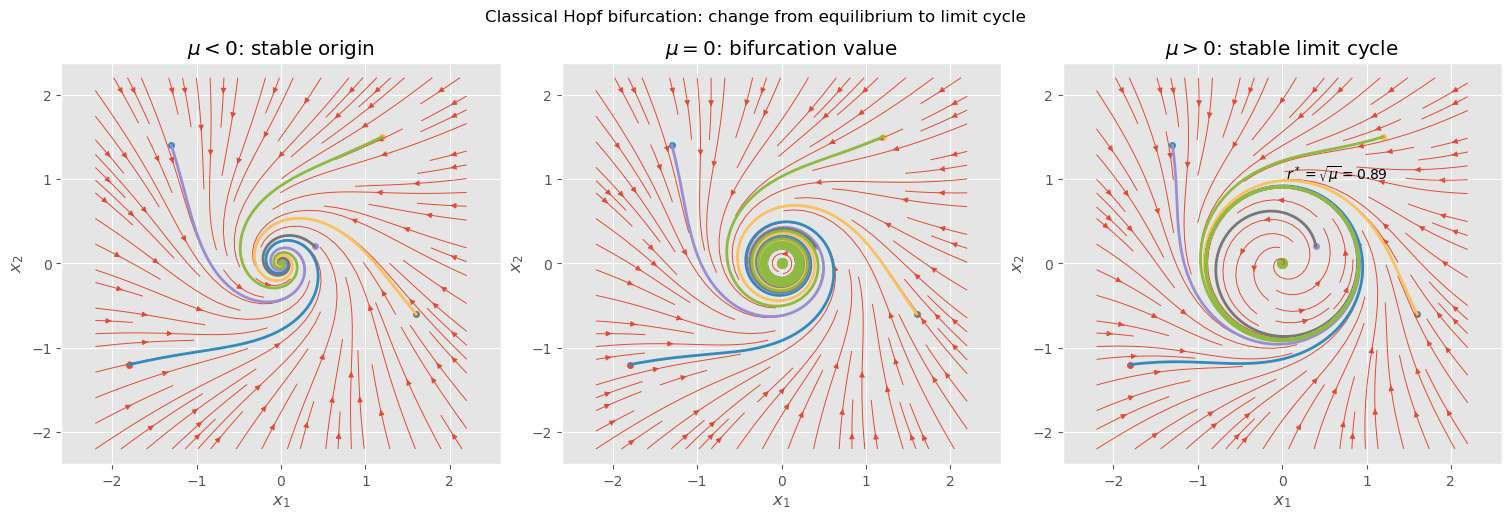

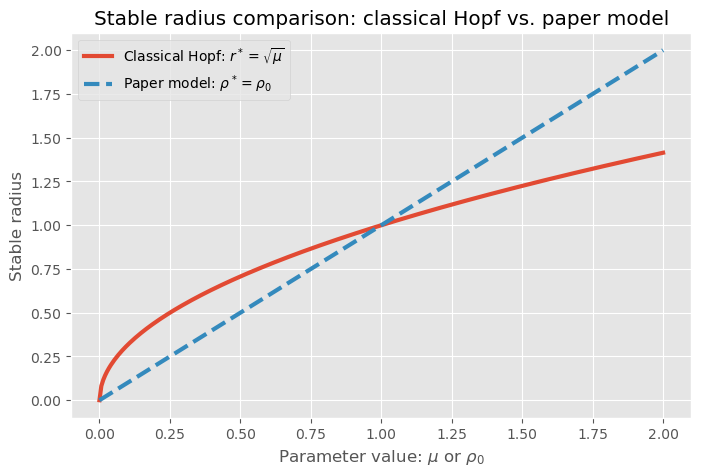

In [40]:
# Numerical comparison: classical Hopf normal form vs. paper's radius parameterization

import numpy as np
import matplotlib.pyplot as plt

def hopf_cartesian(x, mu=1.0, omega=2.0):
    """
    Classical supercritical Hopf normal form in Cartesian coordinates.

    Polar form:
        r_dot = mu*r - r^3
        theta_dot = omega

    Cartesian form:
        x_dot = (mu - r^2)x - omega*y
        y_dot = omega*x + (mu - r^2)y
    """
    x1, x2 = x
    r2 = x1**2 + x2**2

    dx1 = (mu - r2) * x1 - omega * x2
    dx2 = omega * x1 + (mu - r2) * x2

    return np.array([dx1, dx2])


def simulate_hopf(x0, mu=1.0, omega=2.0, dt=0.01, steps=3000):
    xs = np.zeros((steps + 1, 2))
    xs[0] = np.asarray(x0, dtype=float)

    for k in range(steps):
        xs[k + 1] = xs[k] + dt * hopf_cartesian(xs[k], mu=mu, omega=omega)

    return xs


# Initial conditions for phase portraits
initial_conditions = [
    (-1.8, -1.2),
    (-1.3, 1.4),
    (0.4, 0.2),
    (1.6, -0.6),
    (1.2, 1.5),
]

mu_cases = [-0.5, 0.0, 0.8]
case_titles = [
    r"$\mu < 0$: stable origin",
    r"$\mu = 0$: bifurcation value",
    r"$\mu > 0$: stable limit cycle",
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.8), constrained_layout=True)

for ax, mu, title in zip(axes, mu_cases, case_titles):

    # Vector field grid
    x_grid = np.linspace(-2.2, 2.2, 25)
    y_grid = np.linspace(-2.2, 2.2, 25)
    X, Y = np.meshgrid(x_grid, y_grid)

    U = np.zeros_like(X)
    V = np.zeros_like(Y)

    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            vel = hopf_cartesian([X[i, j], Y[i, j]], mu=mu, omega=2.0)
            U[i, j] = vel[0]
            V[i, j] = vel[1]

    ax.streamplot(X, Y, U, V, density=1.0, linewidth=0.7, arrowsize=0.8)

    # Simulated trajectories
    for x0 in initial_conditions:
        xs = simulate_hopf(x0, mu=mu, omega=2.0, dt=0.01, steps=2500)
        ax.plot(xs[:, 0], xs[:, 1], lw=2)
        ax.scatter(xs[0, 0], xs[0, 1], s=20)

    # Limit cycle radius for mu > 0
    if mu > 0:
        r_star = np.sqrt(mu)
        circle = plt.Circle((0, 0), r_star, fill=False, linestyle="--", 
                            linewidth=2)
        ax.add_patch(circle)
        ax.text(0.05, r_star + 0.1, rf"$r^*=\sqrt{{\mu}}={r_star:.2f}$")

    ax.scatter(0, 0, s=60)
    ax.set_title(title)
    ax.set_xlabel(r"$x_1$")
    ax.set_ylabel(r"$x_2$")
    ax.axis("equal")
    ax.set_xlim(-2.2, 2.2)
    ax.set_ylim(-2.2, 2.2)
    ax.grid(True)

plt.suptitle("Classical Hopf bifurcation: change from equilibrium to limit cycle", 
             y=1.05)
plt.show()


# Amplitude/radius law comparison
mu_values = np.linspace(0, 2.0, 300)
classical_radius = np.sqrt(mu_values)

rho0_values = np.linspace(0, 2.0, 300)
paper_radius = rho0_values

plt.figure(figsize=(8, 5))
plt.plot(mu_values, classical_radius, lw=3, label=r"Classical Hopf: $r^*=\sqrt{\mu}$")
plt.plot(rho0_values, paper_radius, "--", lw=3, label=r"Paper model: $\rho^*=\rho_0$")
plt.xlabel(r"Parameter value: $\mu$ or $\rho_0$")
plt.ylabel("Stable radius")
plt.title("Stable radius comparison: classical Hopf vs. paper model")
plt.legend()
plt.grid(True)
plt.show()

**Observation from the numerical comparison:**  
The first set of phase portraits shows the qualitative transition in the classical Hopf normal form. For $\mu<0$, all trajectories spiral into the origin, so the origin is a stable equilibrium point. At $\mu=0$, the system is at the transition value. For $\mu>0$, trajectories no longer converge to the origin; instead, they approach a stable closed orbit of radius $r^*=\sqrt{\mu}$.

The second plot compares the stable-radius law of the classical Hopf model with the radius parameterization used in the paper. In the classical Hopf case, the limit-cycle radius grows nonlinearly as

$$
r^*=\sqrt{\mu}.
$$

In the paper-inspired model, the desired radius is controlled directly as

$$
\rho^*=\rho_0.
$$

Thus, the paper model is not the exact classical Hopf normal form. Rather, it preserves the same qualitative idea: the attracting behavior changes from a point equilibrium to a stable closed orbit. The advantage of the paper’s formulation is that the radius of the cyclic robot motion can be commanded directly, which is more convenient for tasks such as wiping or polishing.

## 3. Mathematical Model Used in This Project

The simplified 2D model used in this notebook follows the paper's polar-coordinate form:

$$
\dot{\rho} = -\sqrt{M}(\rho - \rho_0),
\qquad
\dot{\theta} = R e^{-M^2(\rho - \rho_0)^2}.
$$

Here:

- `rho` is distance from the attractor center.
- `theta` is the angular coordinate.
- `rho0` is the target radius and acts like a bifurcation-like parameter.
- `M > 0` controls radial convergence.
- `R` controls angular speed and rotation direction.

Two behaviors come from the same equation:

- `rho0 = 0`: trajectories converge to a stable point equilibrium.
- `rho0 > 0`: trajectories converge to a stable limit cycle of radius `rho0`.

This is Hopf-inspired rather than an exact classical Hopf normal form. The paper deliberately reparameterizes the system so the limit-cycle radius is directly controllable.

## 4. Cartesian Implementation of the 2D DS

The function below converts Cartesian coordinates to polar coordinates around a chosen center, applies the radial and angular dynamics, and converts the velocity back to Cartesian form. This produces a vector field that can represent either a stable equilibrium or a stable periodic orbit without changing the structure of the equation.

In [41]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("ggplot")
np.set_printoptions(precision=3, suppress=True)


def ds_2d(x, rho0=1.0, M=3.0, R=2.0, center=(0.0, 0.0)):
    """2D Hopf-inspired dynamical system from the paper."""
    x = np.asarray(x, dtype=float)
    c = np.asarray(center, dtype=float)
    y = x - c

    rho = np.linalg.norm(y)
    if rho < 1e-9:
        radial = np.array([1.0, 0.0])
    else:
        radial = y / rho

    tangent = np.array([-radial[1], radial[0]])
    rho_dot = -np.sqrt(M) * (rho - rho0)
    theta_dot = R * np.exp(-(M**2) * (rho - rho0) ** 2)

    return rho_dot * radial + rho * theta_dot * tangent


def simulate_2d(x0, params_fn, dt=0.01, steps=3000):
    """Forward-Euler simulation with possibly time-varying 
       parameters."""
    xs = np.zeros((steps + 1, 2))
    vs = np.zeros((steps, 2))
    xs[0] = np.asarray(x0, dtype=float)
    for k in range(steps):
        params = params_fn(k * dt)
        vs[k] = ds_2d(xs[k], **params)
        xs[k + 1] = xs[k] + dt * vs[k]
    return xs, vs


def constant_params(rho0, M=3.0, R=4.0, center=(0.0, 0.0)):
    return lambda t: {"rho0": rho0, "M": M, "R": R, "center": 
                      center}

## 5. Equilibrium and Stability Analysis

The radial dynamics are

$$
\dot{\rho} = -\sqrt{M}(\rho-\rho_0).
$$

Define the radial error

$$
e = \rho-\rho_0.
$$

Then

$$
\dot{e} = -\sqrt{M}e,
\qquad
e(t)=e(0)e^{-\sqrt{M}t}.
$$

So for `M > 0`, radial error decays exponentially.

**Case A: `rho0 = 0`.** Then `rho(t) -> 0`, so the system converges to the origin. This is the stable equilibrium point case.

**Case B: `rho0 > 0`.** Then `rho(t) -> rho0`. The state does not converge to one point; it converges to the circle

$$
x^2+y^2=\rho_0^2.
$$

This circle is a stable limit cycle, or more generally a stable invariant set.

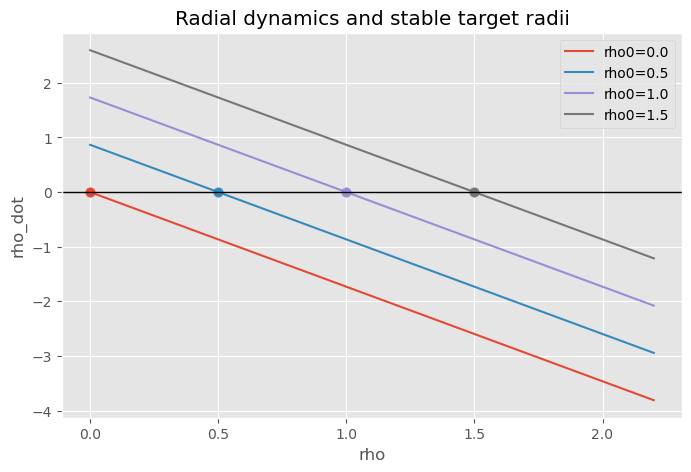

In [42]:
rho0_values = [0.0, 0.5, 1.0, 1.5]
rho = np.linspace(0, 2.2, 300)
M = 3.0

plt.figure(figsize=(8, 5))
for rho0 in rho0_values:
    rho_dot = -np.sqrt(M) * (rho - rho0)
    plt.plot(rho, rho_dot, label=f"rho0={rho0}")
    plt.scatter([rho0], [0], s=45)

plt.axhline(0, color="black", lw=1)
plt.xlabel("rho")
plt.ylabel("rho_dot")
plt.title("Radial dynamics and stable target radii")
plt.legend()
plt.show()

**Observation:**  
This plot shows the radial dynamics of the paper-inspired model. For each value of the target radius $\rho_0$, the curve $\dot{\rho}$ crosses zero at $\rho=\rho_0$. If the current radius is smaller than $\rho_0$, then $\dot{\rho}>0$ and the trajectory moves outward. If the current radius is larger than $\rho_0$, then $\dot{\rho}<0$ and the trajectory moves inward. Hence, the radius always converges toward the stable value $\rho=\rho_0$.

This explains how the same dynamical system produces different attracting sets. When $\rho_0=0$, the stable attracting set is the origin, giving point-attractor behavior. When $\rho_0>0$, the stable attracting set is a circle of radius $\rho_0$, giving limit-cycle behavior.

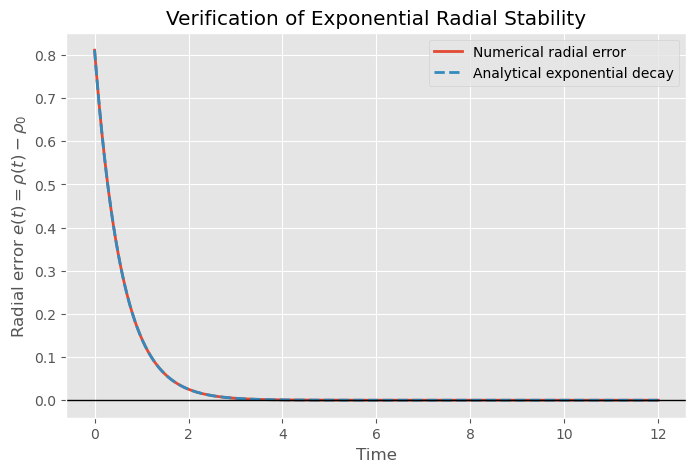

In [43]:
# Stability verification using solve_ivp instead of forward Euler

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

rho0 = 1.0
M = 3.0
R = 4.0

t_end = 12.0
n_eval = 1200
x0 = np.array([1.8, 0.2], dtype=float)

def paper_ds_cartesian(t, x, rho0=1.0, M=3.0, R=4.0):
    """
    Paper-inspired DS in Cartesian coordinates.

    Polar form:
        rho_dot   = -sqrt(M) * (rho - rho0)
        theta_dot = R * exp(-M^2 * (rho - rho0)^2)
    """
    x1, x2 = x
    rho = np.sqrt(x1**2 + x2**2)

    # Avoid division by zero
    if rho < 1e-12:
        return [0.0, 0.0]

    rho_dot = -np.sqrt(M) * (rho - rho0)
    theta_dot = R * np.exp(-(M**2) * (rho - rho0)**2)

    # Cartesian conversion:
    # x_dot = rho_dot * e_r + rho * theta_dot * e_theta
    dx1 = rho_dot * (x1 / rho) - theta_dot * x2
    dx2 = rho_dot * (x2 / rho) + theta_dot * x1

    return [dx1, dx2]


t_eval = np.linspace(0, t_end, n_eval + 1)

sol = solve_ivp(
    lambda t, x: paper_ds_cartesian(t, x, rho0=rho0, M=M, R=R),
    t_span=(0, t_end),
    y0=x0,
    t_eval=t_eval,
    rtol=1e-10,
    atol=1e-12
)

xs = sol.y.T
time = sol.t

rho = np.linalg.norm(xs, axis=1)
e_num = rho - rho0

e0 = e_num[0]
e_analytical = e0 * np.exp(-np.sqrt(M) * time)

plt.figure(figsize=(8, 5))
plt.plot(time, e_num, lw=2, label="Numerical radial error")
plt.plot(time, e_analytical, "--", lw=2, label="Analytical exponential decay")
plt.axhline(0, color="black", lw=1)
plt.xlabel("Time")
plt.ylabel(r"Radial error $e(t)=\rho(t)-\rho_0$")
plt.title("Verification of Exponential Radial Stability")
plt.legend()
plt.grid(True)
plt.show()

**Observation:**  
The numerical radial error closely follows the analytical exponential decay law. This verifies that the radial dynamics are asymptotically stable and that the radius converges to the target value $\rho_0$. Any small mismatch between the two curves can be attributed to numerical integration error, especially because the system contains both radial convergence and rotational motion.

### 5.1 Lyapunov-Function Verification of Radial Stability

To make the stability connection more explicit, we use a Lyapunov-like function for the radial error. The radial dynamics of the paper-inspired system are

$$
\dot{\rho}=-\sqrt{M}(\rho-\rho_0).
$$

Define the radial error as

$$
e=\rho-\rho_0.
$$

Then the error dynamics become

$$
\dot{e}=-\sqrt{M}e.
$$

A natural Lyapunov function for this scalar error dynamics is

$$
V(e)=\frac{1}{2}e^2.
$$

Taking its time derivative along trajectories gives

$$
\dot{V}=e\dot{e}.
$$

Substituting the error dynamics,

$$
\dot{V}=e(-\sqrt{M}e),
$$

and therefore

$$
\dot{V}=-\sqrt{M}e^2 \leq 0.
$$

For \(M>0\), the radial error decreases monotonically. This follows the idea of Lyapunov's direct method: instead of only relying on trajectory plots, we check whether a positive quantity decreases along the motion.

For $\rho_0 = 0$, this proves convergence to the point attractor at the origin. For $\rho_0 > 0$, this proves convergence to the invariant circle

$$
\rho=\rho_0.
$$

Thus, in this system, the Lyapunov function does not always measure convergence to a single point. Instead, it measures convergence to the attracting radial set.

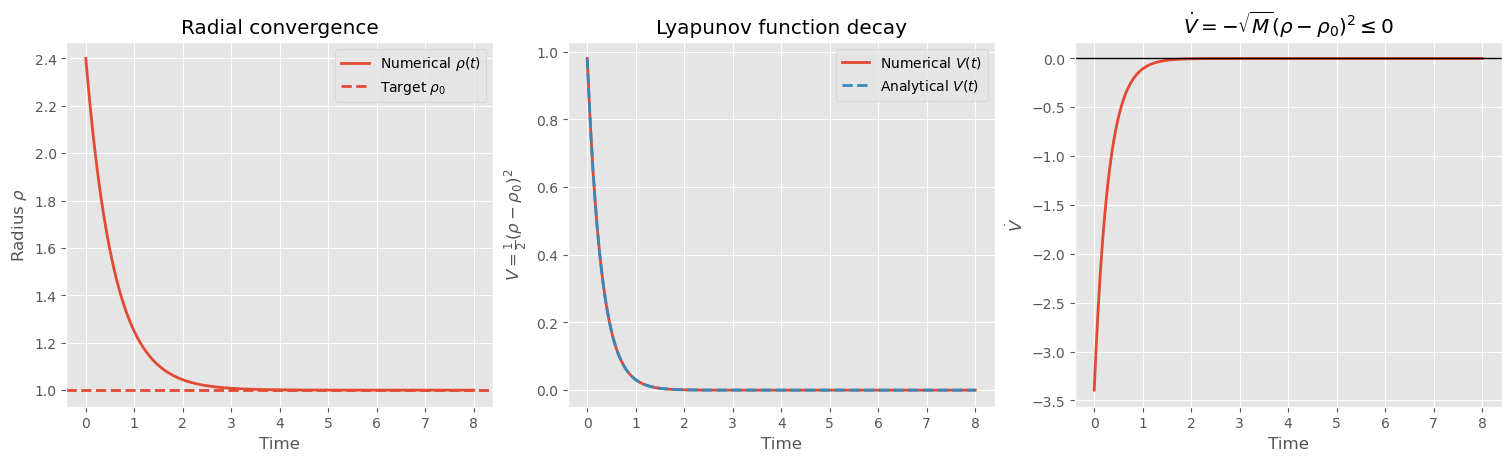

Lyapunov verification
---------------------
Initial radial error e(0)              : 1.400000
Final radial error e(tf)               : 1.343926e-06
Initial Lyapunov value V(0)            : 0.980000
Final Lyapunov value V(tf)             : 9.030681e-13
Maximum value of V_dot                 : -3.128320e-12
Number of numerical increases in V(t)  : 0


In [44]:
from scipy.integrate import solve_ivp
import numpy as np
import matplotlib.pyplot as plt


def paper_polar_rhs(t, z, rho0=1.0, M=3.0, R=4.0):
    """
    Paper DS in polar coordinates:
        rho_dot   = -sqrt(M)*(rho-rho0)
        theta_dot = R*exp(-M^2*(rho-rho0)^2)
    """
    rho, theta = z

    rho_dot = -np.sqrt(M) * (rho - rho0)
    theta_dot = R * np.exp(-(M**2) * (rho - rho0)**2)

    return [rho_dot, theta_dot]


# Parameters for stability verification
rho0 = 1.0
M = 3.0
R = 4.0

rho_initial = 2.4
theta_initial = 0.25

t_end = 8.0
t_eval = np.linspace(0, t_end, 1200)

sol = solve_ivp(
    lambda t, z: paper_polar_rhs(t, z, rho0=rho0, M=M, R=R),
    [0, t_end],
    [rho_initial, theta_initial],
    t_eval=t_eval,
    rtol=1e-10,
    atol=1e-12
)

t = sol.t
rho = sol.y[0]
theta = sol.y[1]

# Radial error
e = rho - rho0

# Lyapunov function and its derivative
V = 0.5 * e**2
V_dot = -np.sqrt(M) * e**2

# Analytical error solution for comparison
e_analytical = e[0] * np.exp(-np.sqrt(M) * t)
V_analytical = 0.5 * e_analytical**2

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), 
                         constrained_layout=True)

# Radius convergence
axes[0].plot(t, rho, lw=2, label=r"Numerical $\rho(t)$")
axes[0].axhline(rho0, ls="--", lw=2, label=r"Target $\rho_0$")
axes[0].set_xlabel("Time")
axes[0].set_ylabel(r"Radius $\rho$")
axes[0].set_title("Radial convergence")
axes[0].legend()
axes[0].grid(True)

# Lyapunov function decay
axes[1].plot(t, V, lw=2, label=r"Numerical $V(t)$")
axes[1].plot(t, V_analytical, "--", lw=2, label=r"Analytical $V(t)$")
axes[1].set_xlabel("Time")
axes[1].set_ylabel(r"$V=\frac{1}{2}(\rho-\rho_0)^2$")
axes[1].set_title("Lyapunov function decay")
axes[1].legend()
axes[1].grid(True)

# V_dot
axes[2].plot(t, V_dot, lw=2)
axes[2].axhline(0, color="black", lw=1)
axes[2].set_xlabel("Time")
axes[2].set_ylabel(r"$\dot{V}$")
axes[2].set_title(r"$\dot{V}=-\sqrt{M}(\rho-\rho_0)^2 \leq 0$")
axes[2].grid(True)

plt.show()


# Numerical checks
num_positive_increases = np.sum(np.diff(V) > 1e-9)

print("Lyapunov verification")
print("---------------------")
print(f"Initial radial error e(0)              : {e[0]:.6f}")
print(f"Final radial error e(tf)               : {e[-1]:.6e}")
print(f"Initial Lyapunov value V(0)            : {V[0]:.6f}")
print(f"Final Lyapunov value V(tf)             : {V[-1]:.6e}")
print(f"Maximum value of V_dot                 : {np.max(V_dot):.6e}")
print(f"Number of numerical increases in V(t)  : {num_positive_increases}")

**Observation:**  

The plot verifies the analytical stability result. The radius $\rho(t)$ converges smoothly to the desired value $\rho_0=1$, and the radial error decreases from $e(0)=1.4$ to approximately $1.34\times 10^{-6}$. The Lyapunov function

$$
V=\frac{1}{2}(\rho-\rho_0)^2
$$

decreases monotonically from $V(0)=0.98$ to approximately $9.03\times 10^{-13}$, with zero numerical increases during the simulation. The third plot also confirms that

$$
\dot{V}\leq 0
$$

throughout the motion. Therefore, the numerical simulation supports the Lyapunov-based result that the radial dynamics are asymptotically stable and that trajectories converge to the attracting radial set $\rho=\rho_0$.

This is important because the radial dynamics behave like a first-order stable system. The angular dynamics generate rotation, while the radial dynamics are responsible for attraction to either the point attractor or the limit cycle.

## 6. Phase Portraits: Point Attractor vs. Limit Cycle

The only parameter changed in the next experiment is `rho0`.

- `rho0 = 0`: the radius decays to zero, so the state converges to the center.
- `rho0 = 1`: the radius converges to one, so the trajectory approaches a closed orbit.

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


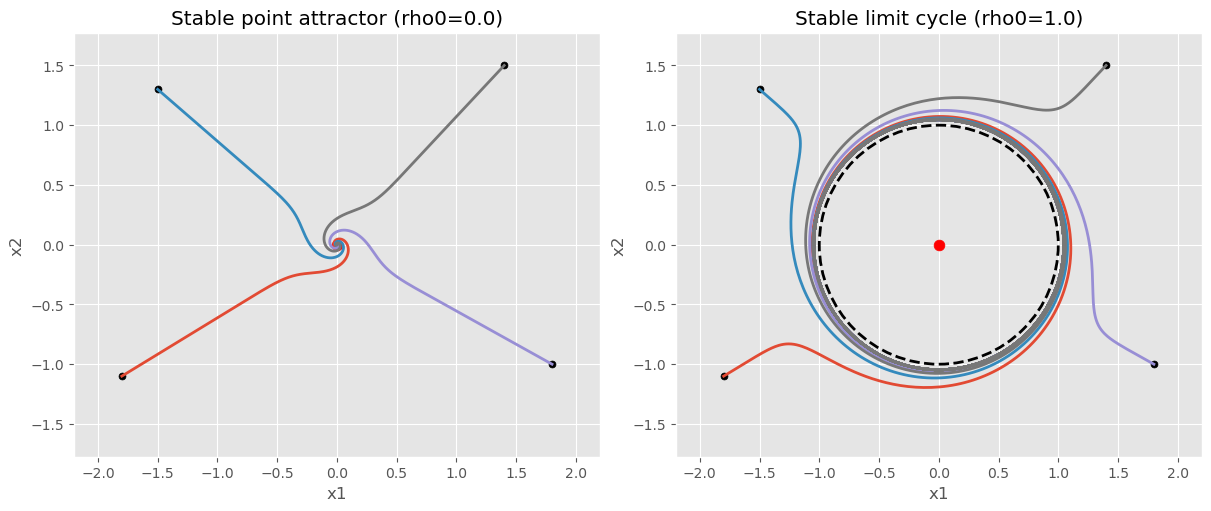

In [45]:
initial_conditions = [(-1.8, -1.1), (-1.5, 1.3), (1.8, -1.0), (1.4, 1.5)]

fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
cases = [(0.0, "Stable point attractor"), (1.0, "Stable limit cycle")]

for ax, (rho0, title) in zip(axes, cases):
    for x0 in initial_conditions:
        xs, _ = simulate_2d(x0, constant_params(rho0=rho0), steps=2500)
        ax.plot(xs[:, 0], xs[:, 1], lw=2)
        ax.scatter(xs[0, 0], xs[0, 1], c="black", s=25)
    if rho0 > 0:
        ax.add_patch(plt.Circle((0, 0), rho0, fill=False, color="black", 
                                ls="--", lw=2))
    ax.scatter(0, 0, c="red", s=60, label="center")
    ax.set_title(title + f" (rho0={rho0})")
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    ax.axis("equal")
    ax.set_xlim(-2.2, 2.2)
    ax.set_ylim(-2.2, 2.2)

plt.show()

**Observation:**  
The phase portraits show that changing only the parameter $\rho_0$ changes the attracting behavior of the same dynamical system. For $\rho_0=0$, all trajectories from different initial conditions spiral inward and converge to the origin. Hence, the origin acts as a stable point attractor.

For $\rho_0=1$, the trajectories do not converge to the center. Instead, they approach the dashed circle of radius $\rho_0=1$. This shows that the attracting set has changed from a point to a closed orbit. Therefore, the same system can generate both reaching-like motion and cyclic motion by changing only the target-radius parameter.

In the robotics interpretation, $\rho_0=0$ corresponds to point-to-point reaching, while $\rho_0>0$ corresponds to rhythmic motion such as wiping or polishing around a desired center.

### 6.1 Numerical Comparison with the Van der Pol Limit Cycle

To connect the paper-inspired dynamical system more directly with the course material, we compare it with the Van der Pol oscillator. The Van der Pol oscillator is a non-conservative nonlinear oscillator that generates a stable limit cycle.

The Van der Pol oscillator is

$$
\ddot{x} + x - \epsilon(1-x^2)\dot{x}=0,
\qquad \epsilon > 0.
$$

Writing it as a first-order system,

$$
\dot{x}=y,
$$

$$
\dot{y}=-x+\epsilon(1-x^2)y.
$$

For small $\epsilon$, the method of averaging gives the slow-flow equation for the oscillation amplitude as

$$
\dot{A}=\frac{\epsilon A}{2}\left(1-\frac{A^2}{4}\right).
$$

This equation has equilibria at

$$
A=0, \qquad A=2.
$$

From the sign of $\dot{A}$, amplitudes smaller than 2 increase and amplitudes larger than 2 decrease. Therefore, $A=2$ is a stable limit-cycle amplitude. This represents the standard idea of an attracting periodic orbit in a nonlinear oscillator.

This comparison is useful because the paper-inspired model also creates a stable limit cycle, but in a more directly controlled way. In the Van der Pol oscillator, the limit-cycle amplitude emerges from the nonlinear damping term. In the paper-inspired model, the final radius is prescribed directly using the parameter $\rho_0$:

$$
\rho^*=\rho_0.
$$

Therefore, the Van der Pol oscillator provides the natural nonlinear-oscillator viewpoint, while the paper-inspired model shows how the same limit-cycle idea can be redesigned into an interpretable robot-motion generator.

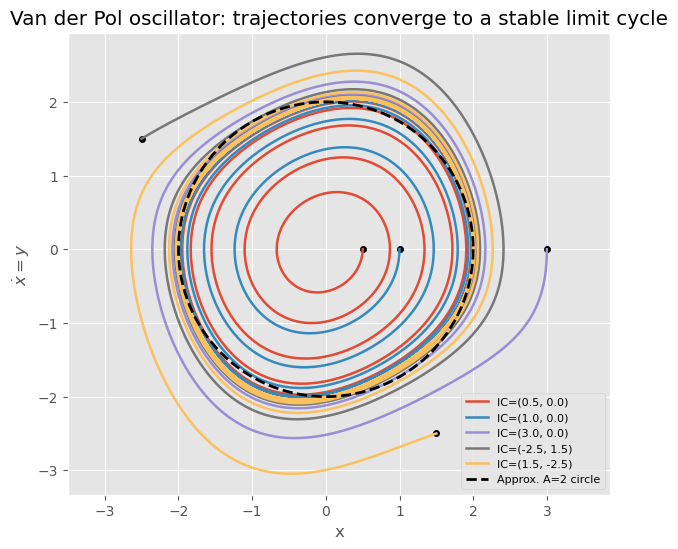

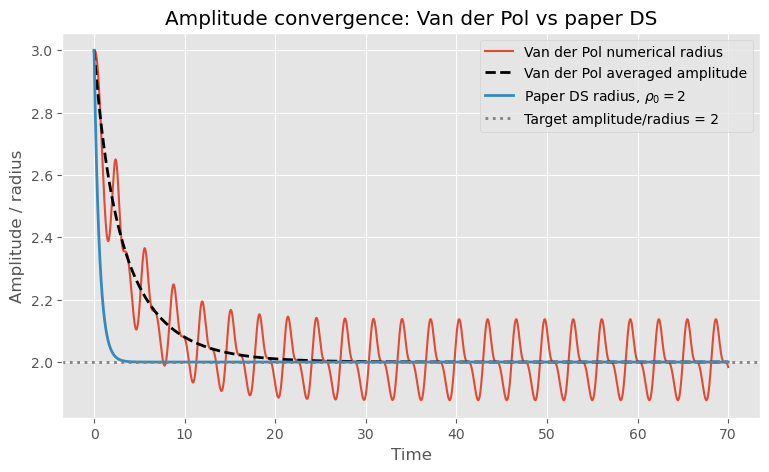

Numerical comparison
--------------------
epsilon used for Van der Pol              : 0.200
Van der Pol averaged stable amplitude     : 2.000
Van der Pol final mean numerical radius   : 2.004
Van der Pol final mean averaged amplitude : 2.000
Paper DS prescribed stable radius rho0    : 2.000
Paper DS final mean numerical radius      : 2.000

Paper DS radius error check
---------------------------
Final radius error                 : 4.946576e-11
Mean radius error over final 20%    : 3.459331e-11
Maximum absolute final-20% error    : 2.978586e-10


In [46]:
from scipy.integrate import solve_ivp
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# Van der Pol oscillator
# ============================================================

def vdp_rhs(t, z, eps=0.2):
    """
    Van der Pol oscillator:
        x_dot = y
        y_dot = -x + eps*(1 - x^2)*y
    """
    x, y = z
    return [y, -x + eps * (1 - x**2) * y]


def simulate_vdp(z0, eps=0.2, t_end=60.0, n=6000):
    t_eval = np.linspace(0, t_end, n)

    sol = solve_ivp(
        lambda t, z: vdp_rhs(t, z, eps),
        [0, t_end],
        z0,
        t_eval=t_eval,
        rtol=1e-9,
        atol=1e-11
    )

    return sol.t, sol.y.T


def averaged_vdp_amplitude(t, B, eps=0.2):
    """
    Averaged amplitude solution for Van der Pol:
        A_dot = eps*A/2 * (1 - A^2/4)

    If A(0)=B, then:
        A^2 = 4*exp(eps*t) / (4/B^2 - 1 + exp(eps*t))
    """
    return np.sqrt(
        4 * np.exp(eps * t) /
        ((4 / B**2) - 1 + np.exp(eps * t))
    )


# ============================================================
# Paper DS integrated directly in polar coordinates
# This removes the artificial steady-state radius error caused
# by Forward Euler integration in Cartesian coordinates.
# ============================================================

def paper_polar_rhs(t, z, rho0=2.0, M=3.0, R=4.0):
    """
    Paper DS in polar coordinates:
        rho_dot   = -sqrt(M)*(rho-rho0)
        theta_dot = R*exp(-M^2*(rho-rho0)^2)
    """
    rho, theta = z

    rho_dot = -np.sqrt(M) * (rho - rho0)
    theta_dot = R * np.exp(-(M**2) * (rho - rho0)**2)

    return [rho_dot, theta_dot]


def simulate_paper_polar(x0, rho0=2.0, M=3.0, R=4.0, t_eval=None):
    """
    Simulates the paper DS in polar coordinates using solve_ivp,
    then converts the result back to Cartesian coordinates.
    """
    x0 = np.asarray(x0, dtype=float)

    rho_init = np.linalg.norm(x0)
    theta_init = np.arctan2(x0[1], x0[0])

    sol = solve_ivp(
        lambda t, z: paper_polar_rhs(t, z, rho0=rho0, M=M, R=R),
        [t_eval[0], t_eval[-1]],
        [rho_init, theta_init],
        t_eval=t_eval,
        rtol=1e-10,
        atol=1e-12
    )

    rho = sol.y[0]
    theta = sol.y[1]

    xs = np.column_stack([
        rho * np.cos(theta),
        rho * np.sin(theta)
    ])

    return xs, rho


# ============================================================
# 1) Phase portrait comparison: Van der Pol stable limit cycle
# ============================================================

eps = 0.2

initial_conditions_vdp = [
    (0.5, 0.0),
    (1.0, 0.0),
    (3.0, 0.0),
    (-2.5, 1.5),
    (1.5, -2.5)
]

plt.figure(figsize=(7, 6))

for z0_ic in initial_conditions_vdp:
    t_vdp_ic, z_vdp_ic = simulate_vdp(z0_ic, eps=eps, t_end=70.0)
    plt.plot(z_vdp_ic[:, 0], z_vdp_ic[:, 1], lw=1.8, label=f"IC={z0_ic}")
    plt.scatter(z_vdp_ic[0, 0], z_vdp_ic[0, 1], c="black", s=20)

# Approximate averaged limit-cycle radius A = 2 for small epsilon
theta_grid = np.linspace(0, 2*np.pi, 400)
plt.plot(
    2*np.cos(theta_grid),
    -2*np.sin(theta_grid),
    "k--",
    lw=2,
    label="Approx. A=2 circle"
)

plt.xlabel("x")
plt.ylabel(r"$\dot{x}=y$")
plt.title("Van der Pol oscillator: trajectories converge to a stable limit cycle")
plt.axis("equal")
plt.legend(loc="best", fontsize=8)
plt.grid(True)
plt.show()


# ============================================================
# 2) Amplitude/radius comparison:
#    Van der Pol vs paper's Hopf-inspired DS
# ============================================================

z0 = (3.0, 0.0)
B = np.linalg.norm(z0)

t_vdp, z_vdp = simulate_vdp(z0, eps=eps, t_end=70.0)
A_num_vdp = np.linalg.norm(z_vdp, axis=1)
A_avg_vdp = averaged_vdp_amplitude(t_vdp, B=B, eps=eps)

# Paper DS with rho0 = 2, matching the averaged Van der Pol limit-cycle amplitude
rho0_compare = 2.0
M_compare = 3.0
R_compare = 4.0

xs_paper, rho_paper = simulate_paper_polar(
    z0,
    rho0=rho0_compare,
    M=M_compare,
    R=R_compare,
    t_eval=t_vdp
)

plt.figure(figsize=(9, 5))

plt.plot(t_vdp, A_num_vdp, lw=1.5, label="Van der Pol numerical radius")
plt.plot(t_vdp, A_avg_vdp, "k--", lw=2, label="Van der Pol averaged amplitude")
plt.plot(t_vdp, rho_paper, lw=2, label=r"Paper DS radius, $\rho_0=2$")
plt.axhline(2.0, color="gray", ls=":", lw=2, label="Target amplitude/radius = 2")

plt.xlabel("Time")
plt.ylabel("Amplitude / radius")
plt.title("Amplitude convergence: Van der Pol vs paper DS")
plt.legend()
plt.grid(True)
plt.show()


# ============================================================
# 3) Numerical summary table
# ============================================================

vdp_final_mean_radius = np.mean(A_num_vdp[int(0.8 * len(A_num_vdp)):])
vdp_final_mean_avg_amp = np.mean(A_avg_vdp[int(0.8 * len(A_avg_vdp)):])
paper_final_mean_radius = np.mean(rho_paper[int(0.8 * len(rho_paper)):])

print("Numerical comparison")
print("--------------------")
print(f"epsilon used for Van der Pol              : {eps:.3f}")
print(f"Van der Pol averaged stable amplitude     : {2.000:.3f}")
print(f"Van der Pol final mean numerical radius   : {vdp_final_mean_radius:.3f}")
print(f"Van der Pol final mean averaged amplitude : {vdp_final_mean_avg_amp:.3f}")
print(f"Paper DS prescribed stable radius rho0    : {rho0_compare:.3f}")
print(f"Paper DS final mean numerical radius      : {paper_final_mean_radius:.3f}")


# ============================================================
# 4) Optional: check final radius error of the paper DS
# ============================================================

paper_radius_error = rho_paper - rho0_compare

print()
print("Paper DS radius error check")
print("---------------------------")
print(f"Final radius error                 : {paper_radius_error[-1]:.6e}")
print(f"Mean radius error over final 20%    : {np.mean(paper_radius_error[int(0.8 * len(paper_radius_error)):]):.6e}")
print(f"Maximum absolute final-20% error    : {np.max(np.abs(paper_radius_error[int(0.8 * len(paper_radius_error)):])):.6e}")

**Observation:**  
The Van der Pol phase portrait shows that trajectories starting from different initial conditions converge to a common stable limit cycle. The dashed circle of radius approximately \(A=2\) represents the averaged limit-cycle amplitude predicted by the method of averaging. The numerical trajectories approach this closed orbit, confirming the stable self-sustained oscillation behavior of the Van der Pol oscillator.

The amplitude-comparison plot shows the main difference between the Van der Pol oscillator and the paper-inspired dynamical system. In the Van der Pol oscillator, the limit-cycle amplitude is generated indirectly through nonlinear damping. The numerical radius oscillates around the averaged amplitude because the actual Van der Pol limit cycle is not perfectly circular. However, its final mean radius is approximately \(2.004\), which is close to the averaged prediction \(A=2\).

In contrast, the paper-inspired dynamical system prescribes the final radius directly using $\rho_0$. For $\rho_0=2$, the radius converges directly to \(2.000\), with a final radius error close to numerical zero. Thus, both systems produce stable limit-cycle behavior, but their mechanisms are different: the Van der Pol oscillator produces the limit cycle naturally through nonlinear damping, while the paper-inspired system designs the limit-cycle radius explicitly for robot motion generation.

The essence of this comparison is that Van der Pol explains how stable limit cycles arise naturally in nonlinear oscillators, while the paper-inspired DS shows how the same idea can be made directly controllable for robotics by prescribing the radius $\rho_0$.

### 6.2 Cycle-by-Cycle Radius Check for the Stable Limit Cycle

The phase portrait visually shows that trajectories approach a closed orbit. To verify this numerically, we sample the trajectory once during every rotation and check whether the sampled radius converges to the target radius.

For the paper-inspired 2D system, the trajectory is sampled whenever it crosses the positive \(x\)-axis, defined by

$$
y=0, \qquad x>0.
$$

At each crossing, the radius is recorded as

$$
\rho_n.
$$

If the closed orbit is attracting, then the sequence of sampled radii should satisfy

$$
\rho_n \rightarrow \rho_0.
$$

This gives a cycle-by-cycle numerical check of limit-cycle stability. Instead of only relying on the spiral shape in the phase portrait, we verify that the radius measured once per revolution approaches the desired stable radius.

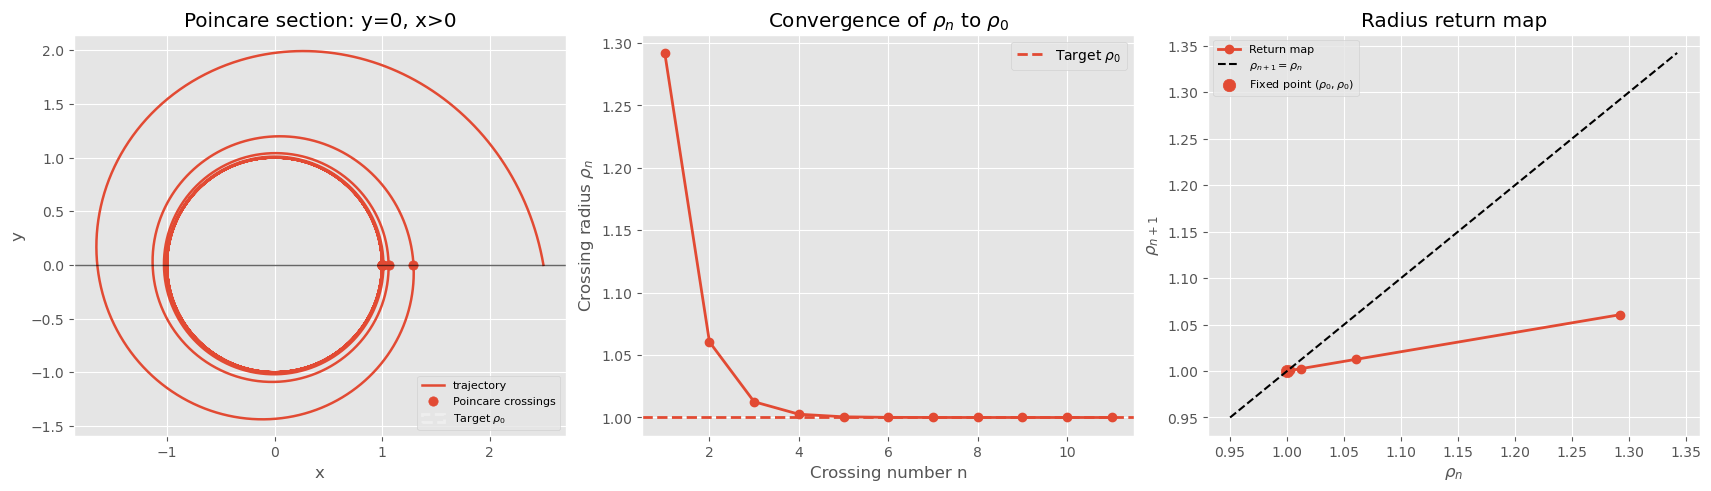

Poincare return-map verification
--------------------------------
Number of crossings detected              : 11
First crossing radius rho_1               : 1.292122
Last crossing radius rho_N                : 1.000000
Target radius rho0                        : 1.000000
Final crossing error rho_N - rho0         : 4.392052e-08
Maximum absolute crossing error           : 0.292122
Final absolute crossing error             : 4.392052e-08


In [ ]:
rho0 = 1.0
M = 0.25      # Smaller M makes convergence slower, so the return map is easier to see
R = 2.0

rho_initial = 2.5
theta_initial = 0.0

t_end = 35.0
t_eval = np.linspace(0, t_end, 9000)

sol = solve_ivp(
    lambda t, z: paper_polar_rhs(t, z, rho0=rho0, M=M, R=R),
    [0, t_end],
    [rho_initial, theta_initial],
    t_eval=t_eval,
    rtol=1e-10,
    atol=1e-12
)

t = sol.t
rho = sol.y[0]
theta_unwrapped = sol.y[1]

# Convert to Cartesian for plotting
x = rho * np.cos(theta_unwrapped)
y = rho * np.sin(theta_unwrapped)

# Poincare section: y = 0, x > 0
# In polar coordinates this corresponds to theta = 2*pi*n.
max_crossing_index = int(theta_unwrapped[-1] // (2*np.pi))
crossing_angles = 2 * np.pi * np.arange(1, max_crossing_index + 1)

# Interpolate rho at every crossing angle
rho_crossings = np.interp(crossing_angles, theta_unwrapped, rho)

# Cartesian crossing points
x_crossings = rho_crossings * np.cos(crossing_angles)
y_crossings = rho_crossings * np.sin(crossing_angles)

crossing_number = np.arange(1, len(rho_crossings) + 1)

fig, axes = plt.subplots(1, 3, figsize=(17, 4.8), 
                         constrained_layout=True)

# 1) Phase portrait with Poincare crossings
axes[0].plot(x, y, lw=1.8, label="trajectory")
axes[0].scatter(x_crossings, y_crossings, s=45, label="Poincare crossings")
axes[0].add_patch(plt.Circle((0, 0), rho0, fill=False, ls="--", lw=2, 
                             label=r"Target $\rho_0$"))
axes[0].axhline(0, color="black", lw=1, alpha=0.6)
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].set_title("Poincare section: y=0, x>0")
axes[0].axis("equal")
axes[0].legend(fontsize=8)
axes[0].grid(True)

# 2) Radius at each crossing
axes[1].plot(crossing_number, rho_crossings, marker="o", lw=2)
axes[1].axhline(rho0, ls="--", lw=2, label=r"Target $\rho_0$")
axes[1].set_xlabel("Crossing number n")
axes[1].set_ylabel(r"Crossing radius $\rho_n$")
axes[1].set_title(r"Convergence of $\rho_n$ to $\rho_0$")
axes[1].legend()
axes[1].grid(True)

# 3) Return map rho_{n+1} vs rho_n
rho_n = rho_crossings[:-1]
rho_np1 = rho_crossings[1:]

axes[2].plot(rho_n, rho_np1, marker="o", lw=2, label=r"Return map")
min_r = min(np.min(rho_n), np.min(rho_np1), rho0) - 0.05
max_r = max(np.max(rho_n), np.max(rho_np1), rho0) + 0.05
axes[2].plot([min_r, max_r], [min_r, max_r], "k--", lw=1.5, label=r"$\rho_{n+1}=\rho_n$")
axes[2].scatter([rho0], [rho0], s=80, label=r"Fixed point $(\rho_0,\rho_0)$")
axes[2].set_xlabel(r"$\rho_n$")
axes[2].set_ylabel(r"$\rho_{n+1}$")
axes[2].set_title("Radius return map")
axes[2].legend(fontsize=8)
axes[2].grid(True)

plt.show()


# Numerical summary
print("Poincare return-map verification")
print("--------------------------------")
print(f"Number of crossings detected              : {len(rho_crossings)}")
print(f"First crossing radius rho_1               : {rho_crossings[0]:.6f}")
print(f"Last crossing radius rho_N                : {rho_crossings[-1]:.6f}")
print(f"Target radius rho0                        : {rho0:.6f}")
print(f"Final crossing error rho_N - rho0         : {rho_crossings[-1] - rho0:.6e}")
print(f"Maximum absolute crossing error           : {np.max(np.abs(rho_crossings - rho0)):.6f}")
print(f"Final absolute crossing error             : {abs(rho_crossings[-1] - rho0):.6e}")

**Observation:**  
The cycle-by-cycle radius check confirms that the closed orbit is attracting. In the first plot, the trajectory spirals toward the target circle of radius $\rho_0=1$, and the sampled crossing points on the positive \(x\)-axis move closer to the target circle after every rotation.

The second plot shows this convergence quantitatively. The first recorded crossing radius is

$$
\rho_1 = 1.292122,
$$

while the final recorded crossing radius is

$$
\rho_N = 1.000000.
$$

The final crossing error is only

$$
\rho_N-\rho_0 = 4.39\times 10^{-8},
$$

which is practically zero.

The return-map plot also supports the same conclusion. The sampled pairs $(\rho_n,\rho_{n+1})$ move toward the fixed point

$$
(\rho_0,\rho_0) = (1,1).
$$

Therefore, the numerical check verifies that the radius converges to the stable value $\rho_0$ once per cycle. This confirms that the limit cycle is attracting, not just visually closed in the phase portrait.

## 7. Radius-Parameterized Transition from Point Attractor to Limit Cycle

A useful way to summarize the effect of the parameter $\rho_0$ is to plot the stable attracting radius as $\rho_0$ is varied. For the paper-inspired dynamical system, the stable radial set is

$$
\rho^*=\rho_0.
$$

Therefore, when $\rho_0=0$, the attracting set is the origin. When $\rho_0>0$, the attracting set becomes a closed orbit of radius $\rho_0$.

This plot is not treated as a classical Hopf bifurcation diagram. Instead, it is used as a parameter-sweep diagram showing how the same dynamical system transitions from point-attractor behavior to limit-cycle behavior as the target radius is increased.

**Observation:**  
The stable attracting radius increases directly with $\rho_0$. At $\rho_0=0$, the stable radius is zero, so the trajectory converges to the point equilibrium at the origin. As $\rho_0$ increases, the stable radius increases linearly, and the trajectory converges to a closed orbit of the corresponding radius.

The phase portraits confirm the same behavior visually. For $\rho_0=0$, the trajectory spirals into the origin. For $\rho_0=0.3$, $0.8$, and $1.2$, the trajectory converges to closed orbits of increasing radius. Thus, changing only $\rho_0$ changes the attracting behavior from reaching-like motion to cyclic motion with a prescribed radius.

The main significance is that the radius of the rhythmic motion is directly commanded through $\rho_0$. This makes the model suitable for robot-motion generation, where the size of a wiping or circular motion should be specified explicitly.

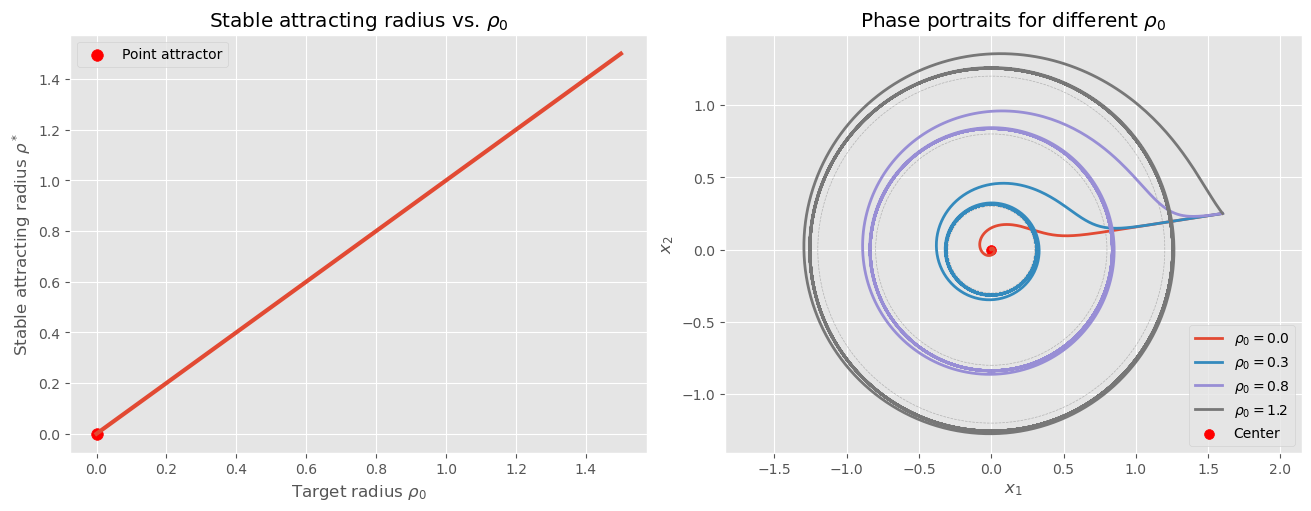

In [52]:
rho0_grid = np.linspace(0, 1.5, 100)
stable_radius = rho0_grid

fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)

# ------------------------------------------------------------
# 1) Stable attracting radius as rho0 changes
# ------------------------------------------------------------
axes[0].plot(rho0_grid, stable_radius, lw=3)
axes[0].scatter([0], [0], c="red", s=70, label="Point attractor")

axes[0].set_xlabel(r"Target radius $\rho_0$")
axes[0].set_ylabel(r"Stable attracting radius $\rho^*$")
axes[0].set_title(r"Stable attracting radius vs. $\rho_0$")
axes[0].legend()
axes[0].grid(True)

# ------------------------------------------------------------
# 2) Phase portraits for different rho0 values
# ------------------------------------------------------------
rho0_cases = [0.0, 0.3, 0.8, 1.2]
x0 = (1.6, 0.25)

for rho0 in rho0_cases:
    xs, _ = simulate_2d(
        x0,
        constant_params(rho0=rho0),
        steps=1800
    )

    axes[1].plot(xs[:, 0], xs[:, 1], lw=2, label=rf"$\rho_0={rho0}$")

    if rho0 > 0:
        axes[1].add_patch(
            plt.Circle(
                (0, 0),
                rho0,
                fill=False,
                color="gray",
                ls="--",
                alpha=0.5
            )
        )

axes[1].scatter(0, 0, c="red", s=50, label="Center")
axes[1].axis("equal")
axes[1].set_title(r"Phase portraits for different $\rho_0$")
axes[1].set_xlabel(r"$x_1$")
axes[1].set_ylabel(r"$x_2$")
axes[1].legend()
axes[1].grid(True)

plt.show()

**Observation:**  
The left plot shows that the stable attracting radius varies linearly with the target-radius parameter $\rho_0$. When $\rho_0=0$, the stable radius is zero, so the attracting set is the point at the origin. As $\rho_0$ increases, the stable radius increases directly according to

$$
\rho^*=\rho_0.
$$

The right plot confirms this behavior in the phase portrait. For $\rho_0=0$, the trajectory spirals into the center. For $\rho_0=0.3$, $0.8$, and $1.2$, the trajectory converges to closed orbits of increasing radius. Thus, by changing only $\rho_0$, the same dynamical system changes from point-attractor behavior to limit-cycle behavior.

The key result is that the size of the cyclic motion is directly controllable through $\rho_0$, which is useful for robot tasks where the radius of wiping, polishing, or circular motion must be specified explicitly.

## 8. Effect of Parameters `M`, `R`, and `rho0`

The paper emphasizes interpretable parameters. In this implementation:

- Increasing `rho0` increases the final orbit radius.
- Increasing `M` increases radial convergence speed.
- Changing the sign of `R` changes rotation direction.

This is important for robotics because the same learned DS can be reused while the user changes speed, amplitude, center, and direction.

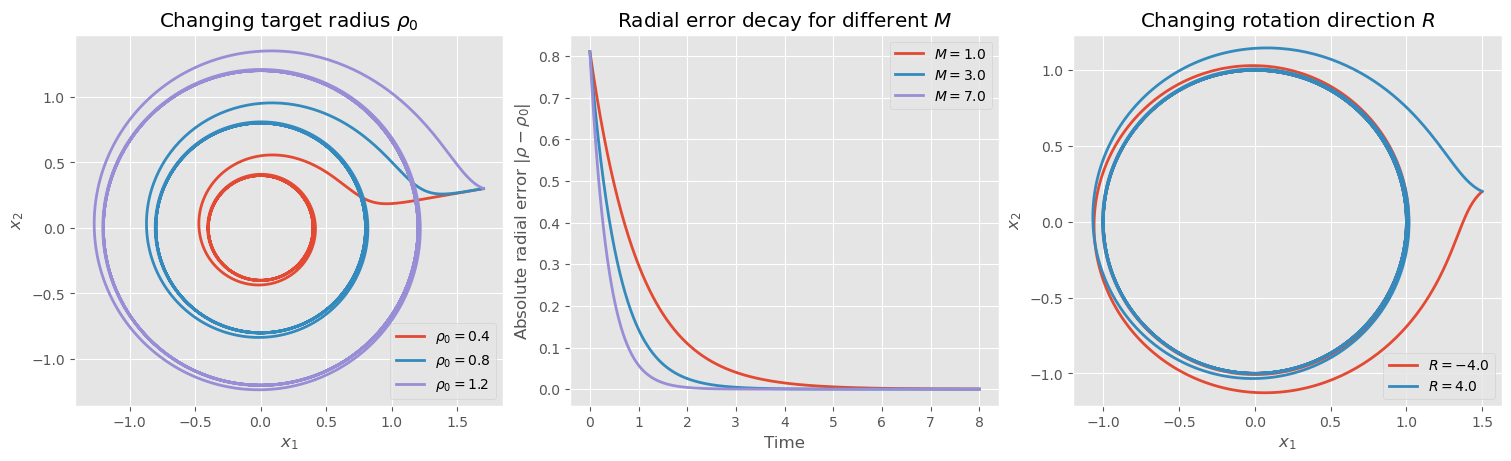

In [53]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp


def paper_polar_rhs(t, z, rho0=1.0, M=3.0, R=4.0):
    """
    Paper-inspired DS in polar coordinates:
        rho_dot   = -sqrt(M)*(rho-rho0)
        theta_dot = R*exp(-M^2*(rho-rho0)^2)
    """
    rho, theta = z

    rho_dot = -np.sqrt(M) * (rho - rho0)
    theta_dot = R * np.exp(-(M**2) * (rho - rho0)**2)

    return [rho_dot, theta_dot]


def simulate_paper_polar(x0, rho0=1.0, M=3.0, R=4.0, t_end=12.0, n=1200):
    """
    Simulates the paper-inspired DS in polar coordinates
    and converts the result back to Cartesian coordinates.
    """
    x0 = np.asarray(x0, dtype=float)

    rho_initial = np.linalg.norm(x0)
    theta_initial = np.arctan2(x0[1], x0[0])

    t_eval = np.linspace(0, t_end, n + 1)

    sol = solve_ivp(
        lambda t, z: paper_polar_rhs(t, z, rho0=rho0, M=M, R=R),
        [0, t_end],
        [rho_initial, theta_initial],
        t_eval=t_eval,
        rtol=1e-10,
        atol=1e-12
    )

    t = sol.t
    rho = sol.y[0]
    theta = sol.y[1]

    xs = np.column_stack([
        rho * np.cos(theta),
        rho * np.sin(theta)
    ])

    return t, xs, rho


fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), constrained_layout=True)

# ------------------------------------------------------------
# 1) Effect of rho0: target radius / limit-cycle size
# ------------------------------------------------------------
for rho0 in [0.4, 0.8, 1.2]:
    t, xs, rho = simulate_paper_polar(
        x0=(1.7, 0.3),
        rho0=rho0,
        M=3.0,
        R=4.0,
        t_end=10.0,
        n=1200
    )

    axes[0].plot(xs[:, 0], xs[:, 1], lw=2, label=rf"$\rho_0={rho0}$")
    axes[0].add_patch(
        plt.Circle((0, 0), rho0, fill=False, ls="--", alpha=0.5)
    )

axes[0].axis("equal")
axes[0].set_title(r"Changing target radius $\rho_0$")
axes[0].set_xlabel(r"$x_1$")
axes[0].set_ylabel(r"$x_2$")
axes[0].legend()
axes[0].grid(True)


# ------------------------------------------------------------
# 2) Effect of M: radial convergence rate
# ------------------------------------------------------------
rho0_fixed = 1.0

for M_val in [1.0, 3.0, 7.0]:
    t, xs, rho = simulate_paper_polar(
        x0=(1.8, 0.2),
        rho0=rho0_fixed,
        M=M_val,
        R=4.0,
        t_end=8.0,
        n=1000
    )

    radius_error = np.abs(rho - rho0_fixed)
    axes[1].plot(t, radius_error, lw=2, label=rf"$M={M_val}$")

axes[1].set_title(r"Radial error decay for different $M$")
axes[1].set_xlabel("Time")
axes[1].set_ylabel(r"Absolute radial error $|\rho-\rho_0|$")
axes[1].legend()
axes[1].grid(True)


# ------------------------------------------------------------
# 3) Effect of R: rotation direction
# ------------------------------------------------------------
for R_val in [-4.0, 4.0]:
    t, xs, rho = simulate_paper_polar(
        x0=(1.5, 0.2),
        rho0=1.0,
        M=3.0,
        R=R_val,
        t_end=8.0,
        n=1000
    )

    axes[2].plot(xs[:, 0], xs[:, 1], lw=2, label=rf"$R={R_val}$")

axes[2].add_patch(
    plt.Circle((0, 0), 1.0, fill=False, ls="--", alpha=0.5)
)
axes[2].axis("equal")
axes[2].set_title(r"Changing rotation direction $R$")
axes[2].set_xlabel(r"$x_1$")
axes[2].set_ylabel(r"$x_2$")
axes[2].legend()
axes[2].grid(True)

plt.show()

**Observation:**  
These plots show the role of the three main parameters in the paper-inspired dynamical system. The parameter $\rho_0$ directly controls the final attracting radius. As $\rho_0$ increases from $0.4$ to $1.2$, the trajectory converges to larger closed orbits, showing that the size of the cyclic motion can be prescribed directly.

The parameter $M$ controls the radial convergence rate. Larger values of $M$ make the radial error $|\rho-\rho_0|$ decay faster, so the trajectory reaches the desired orbit more quickly. This agrees with the radial dynamics

$$
\dot{\rho}=-\sqrt{M}(\rho-\rho_0).
$$

The parameter $R$ controls the angular motion. Changing the sign of $R$ reverses the direction of rotation, while the trajectory still converges to the same target radius. Thus, $\rho_0$ controls the orbit size, $M$ controls the convergence speed, and $R$ controls the rotation direction and angular speed.

## 9. Smooth Parameter Switching vs. Hard Switching

The paper's practical motivation is that switching between separate DSs can create abrupt transients. In a switched system, the vector field can change discontinuously at the switching time.

Here we compare two cases:

- **Hard switching:** use a linear reaching controller, then suddenly switch to the limit-cycle DS.
- **Smooth parameter switching:** keep the same DS structure and smoothly ramp `rho0` from 0 to 1.

This connects directly to switched systems, discontinuity in vector fields, smooth transitions, and robustness.

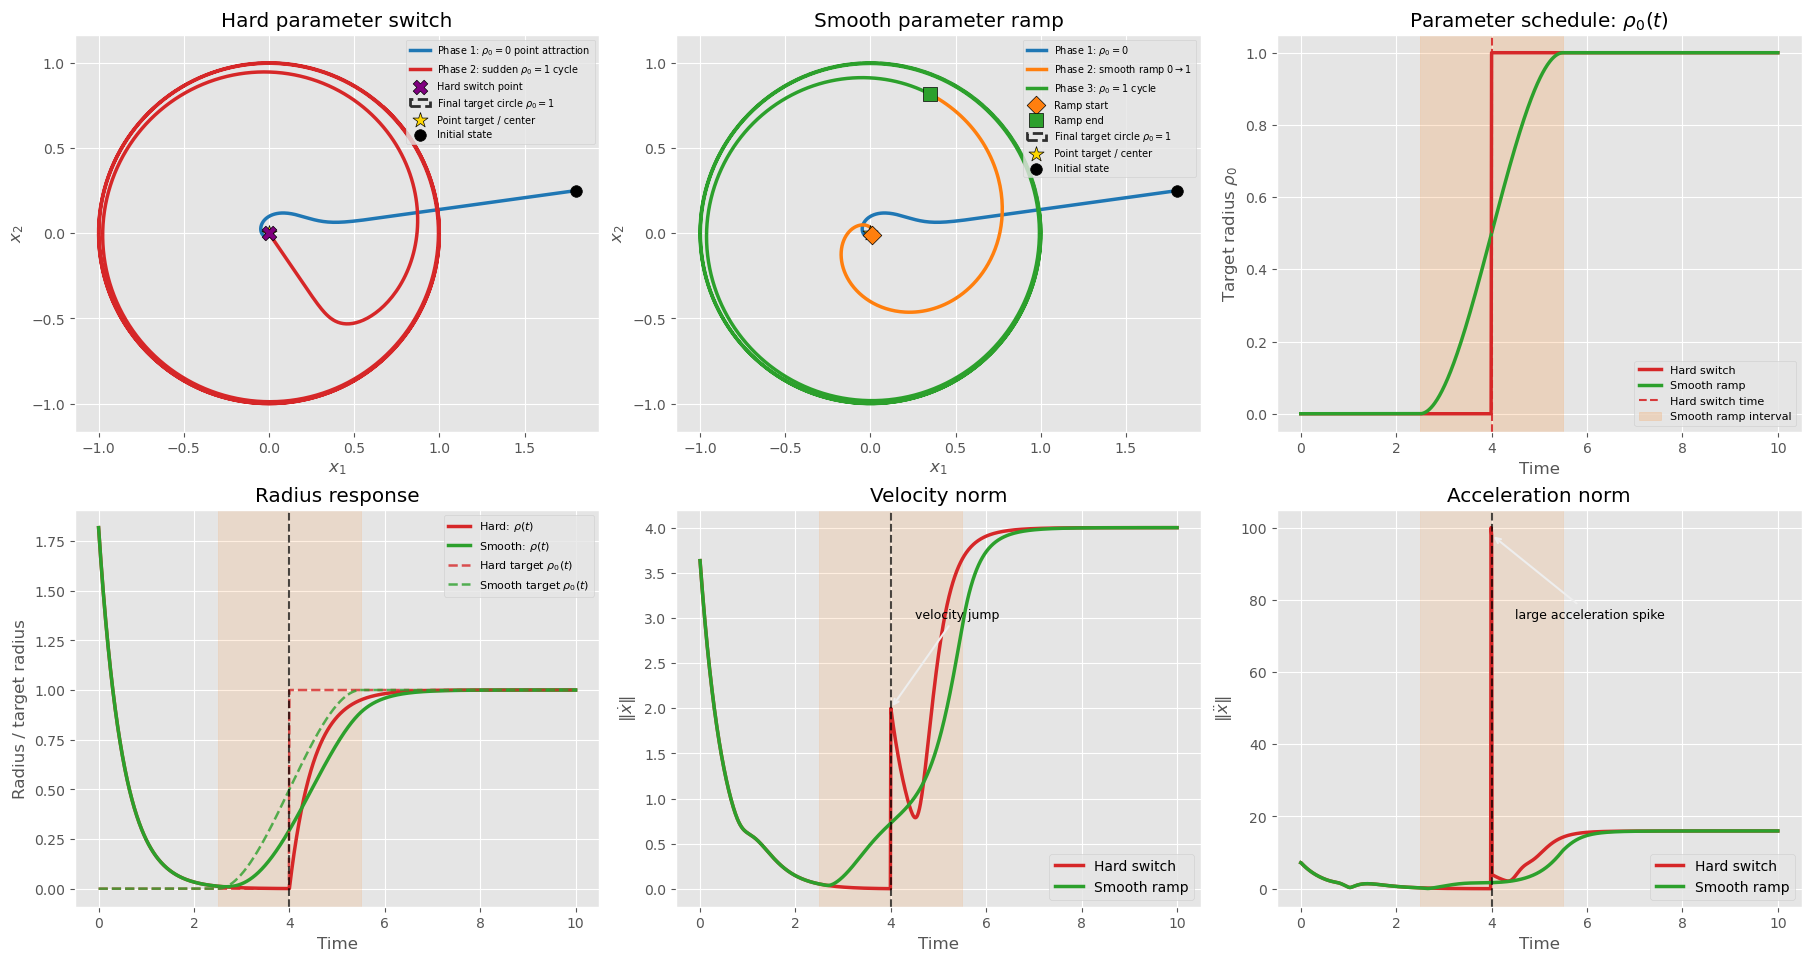

Switching comparison
--------------------
Initial state                          : (1.800, 0.250)
Point target / center                  : (0.000, 0.000)
Final target limit-cycle radius        : 1.000
Hard switch time                       : 4.00 s
Smooth ramp interval                   : 2.50 s to 5.50 s
Velocity jump at hard switch           : 2.000001
Peak acceleration norm, hard switching : 99.992230
Peak acceleration norm, smooth ramp    : 15.998766


In [55]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp


def smoothstep(s):
    s = np.clip(s, 0.0, 1.0)
    return s * s * (3.0 - 2.0 * s)


def ds_cartesian(x, rho0=1.0, M=4.0, R=4.0, center=(0.0, 0.0)):
    """
    Paper-inspired DS in Cartesian coordinates.

    Polar form:
        rho_dot   = -sqrt(M)*(rho-rho0)
        theta_dot = R*exp(-M^2*(rho-rho0)^2)
    """
    x = np.asarray(x, dtype=float)
    c = np.asarray(center, dtype=float)
    rel = x - c

    rho = np.linalg.norm(rel)

    if rho < 1e-10:
        return np.zeros(2)

    rho_dot = -np.sqrt(M) * (rho - rho0)
    theta_dot = R * np.exp(-(M**2) * (rho - rho0)**2)

    e_r = rel / rho
    e_theta = np.array([-e_r[1], e_r[0]])

    v = rho_dot * e_r + rho * theta_dot * e_theta
    return v


# ------------------------------------------------------------
# Parameter schedules
# ------------------------------------------------------------
M = 4.0
R = 4.0
rho_final = 1.0
center = np.array([0.0, 0.0])

t_switch = 4.0
ramp_start = 2.5
ramp_end = 5.5

def rho0_hard(t):
    return 0.0 if t < t_switch else rho_final

def rho0_smooth(t):
    s = (t - ramp_start) / (ramp_end - ramp_start)
    return rho_final * smoothstep(s)

def rhs_hard(t, x):
    return ds_cartesian(x, rho0=rho0_hard(t), M=M, R=R, center=center)

def rhs_smooth(t, x):
    return ds_cartesian(x, rho0=rho0_smooth(t), M=M, R=R, center=center)


# ------------------------------------------------------------
# Simulation
# ------------------------------------------------------------
x0 = np.array([1.8, 0.25])
t_end = 10.0
dt = 0.01
t_eval = np.arange(0.0, t_end + dt, dt)

sol_hard = solve_ivp(
    rhs_hard,
    [0, t_end],
    x0,
    t_eval=t_eval,
    rtol=1e-9,
    atol=1e-11
)

sol_smooth = solve_ivp(
    rhs_smooth,
    [0, t_end],
    x0,
    t_eval=t_eval,
    rtol=1e-9,
    atol=1e-11
)

t = sol_hard.t
hard_xs = sol_hard.y.T
smooth_xs = sol_smooth.y.T

# Velocities evaluated from vector field
hard_vs = np.array([rhs_hard(ti, xi) for ti, xi in zip(t, hard_xs)])
smooth_vs = np.array([rhs_smooth(ti, xi) for ti, xi in zip(t, smooth_xs)])

hard_speed = np.linalg.norm(hard_vs, axis=1)
smooth_speed = np.linalg.norm(smooth_vs, axis=1)

# Finite-difference acceleration as smoothness indicator
hard_acc = np.gradient(hard_vs, dt, axis=0)
smooth_acc = np.gradient(smooth_vs, dt, axis=0)

hard_acc_norm = np.linalg.norm(hard_acc, axis=1)
smooth_acc_norm = np.linalg.norm(smooth_acc, axis=1)

# Radius and parameter profiles
hard_rho = np.linalg.norm(hard_xs - center, axis=1)
smooth_rho = np.linalg.norm(smooth_xs - center, axis=1)

hard_rho0_profile = np.array([rho0_hard(ti) for ti in t])
smooth_rho0_profile = np.array([rho0_smooth(ti) for ti in t])

# Important indices
idx_switch = np.argmin(np.abs(t - t_switch))
idx_ramp_start = np.argmin(np.abs(t - ramp_start))
idx_ramp_end = np.argmin(np.abs(t - ramp_end))

# Velocity jump at hard switch
x_switch = hard_xs[idx_switch]
v_before = ds_cartesian(x_switch, rho0=0.0, M=M, R=R, center=center)
v_after = ds_cartesian(x_switch, rho0=rho_final, M=M, R=R, center=center)
velocity_jump = np.linalg.norm(v_after - v_before)


# ------------------------------------------------------------
# Helper functions for plotting
# ------------------------------------------------------------
def plot_segment(ax, xs, i0, i1, color, label, lw=2.5):
    ax.plot(xs[i0:i1+1, 0], xs[i0:i1+1, 1], color=color, lw=lw, label=label)


def decorate_phase_plot(ax, title):
    # Final target limit cycle
    ax.add_patch(
        plt.Circle(
            center,
            rho_final,
            fill=False,
            color="black",
            ls="--",
            lw=2,
            alpha=0.8,
            label=r"Final target circle $\rho_0=1$"
        )
    )

    # Point target at center
    ax.scatter(
        center[0], center[1],
        s=130,
        marker="*",
        color="gold",
        edgecolor="black",
        zorder=5,
        label="Point target / center"
    )

    # Initial point
    ax.scatter(
        x0[0], x0[1],
        s=70,
        marker="o",
        color="black",
        zorder=5,
        label="Initial state"
    )

    ax.set_title(title)
    ax.set_xlabel(r"$x_1$")
    ax.set_ylabel(r"$x_2$")
    ax.axis("equal")
    ax.grid(True)


# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(18, 9.5), constrained_layout=True)

# ------------------------------------------------------------
# 1) Hard switching trajectory with colored phases
# ------------------------------------------------------------
plot_segment(
    axes[0, 0],
    hard_xs,
    0,
    idx_switch,
    color="tab:blue",
    label=r"Phase 1: $\rho_0=0$ point attraction"
)

plot_segment(
    axes[0, 0],
    hard_xs,
    idx_switch,
    len(hard_xs) - 1,
    color="tab:red",
    label=r"Phase 2: sudden $\rho_0=1$ cycle"
)

axes[0, 0].scatter(
    hard_xs[idx_switch, 0],
    hard_xs[idx_switch, 1],
    s=110,
    marker="X",
    color="purple",
    edgecolor="black",
    zorder=6,
    label="Hard switch point"
)

decorate_phase_plot(axes[0, 0], "Hard parameter switch")
axes[0, 0].legend(fontsize=7, loc="best")


# ------------------------------------------------------------
# 2) Smooth switching trajectory with colored phases
# ------------------------------------------------------------
plot_segment(
    axes[0, 1],
    smooth_xs,
    0,
    idx_ramp_start,
    color="tab:blue",
    label=r"Phase 1: $\rho_0=0$"
)

plot_segment(
    axes[0, 1],
    smooth_xs,
    idx_ramp_start,
    idx_ramp_end,
    color="tab:orange",
    label=r"Phase 2: smooth ramp $0\to1$"
)

plot_segment(
    axes[0, 1],
    smooth_xs,
    idx_ramp_end,
    len(smooth_xs) - 1,
    color="tab:green",
    label=r"Phase 3: $\rho_0=1$ cycle"
)

axes[0, 1].scatter(
    smooth_xs[idx_ramp_start, 0],
    smooth_xs[idx_ramp_start, 1],
    s=90,
    marker="D",
    color="tab:orange",
    edgecolor="black",
    zorder=6,
    label="Ramp start"
)

axes[0, 1].scatter(
    smooth_xs[idx_ramp_end, 0],
    smooth_xs[idx_ramp_end, 1],
    s=90,
    marker="s",
    color="tab:green",
    edgecolor="black",
    zorder=6,
    label="Ramp end"
)

decorate_phase_plot(axes[0, 1], "Smooth parameter ramp")
axes[0, 1].legend(fontsize=7, loc="best")


# ------------------------------------------------------------
# 3) rho0 profile
# ------------------------------------------------------------
axes[0, 2].plot(t, hard_rho0_profile, lw=2.5, color="tab:red", label="Hard switch")
axes[0, 2].plot(t, smooth_rho0_profile, lw=2.5, color="tab:green", label="Smooth ramp")

axes[0, 2].axvline(t_switch, color="tab:red", ls="--", alpha=0.9, label="Hard switch time")
axes[0, 2].axvspan(ramp_start, ramp_end, color="tab:orange", alpha=0.18, label="Smooth ramp interval")

axes[0, 2].set_title(r"Parameter schedule: $\rho_0(t)$")
axes[0, 2].set_xlabel("Time")
axes[0, 2].set_ylabel(r"Target radius $\rho_0$")
axes[0, 2].legend(fontsize=8)
axes[0, 2].grid(True)


# ------------------------------------------------------------
# 4) Radius response
# ------------------------------------------------------------
axes[1, 0].plot(t, hard_rho, lw=2.5, color="tab:red", label=r"Hard: $\rho(t)$")
axes[1, 0].plot(t, smooth_rho, lw=2.5, color="tab:green", label=r"Smooth: $\rho(t)$")
axes[1, 0].plot(t, hard_rho0_profile, "--", lw=1.8, color="tab:red", alpha=0.8, label=r"Hard target $\rho_0(t)$")
axes[1, 0].plot(t, smooth_rho0_profile, "--", lw=1.8, color="tab:green", alpha=0.8, label=r"Smooth target $\rho_0(t)$")

axes[1, 0].axvline(t_switch, color="black", ls="--", alpha=0.7)
axes[1, 0].axvspan(ramp_start, ramp_end, color="tab:orange", alpha=0.12)

axes[1, 0].set_title("Radius response")
axes[1, 0].set_xlabel("Time")
axes[1, 0].set_ylabel(r"Radius / target radius")
axes[1, 0].legend(fontsize=8)
axes[1, 0].grid(True)


# ------------------------------------------------------------
# 5) Velocity norm
# ------------------------------------------------------------
axes[1, 1].plot(t, hard_speed, lw=2.5, color="tab:red", label="Hard switch")
axes[1, 1].plot(t, smooth_speed, lw=2.5, color="tab:green", label="Smooth ramp")

axes[1, 1].axvline(t_switch, color="black", ls="--", alpha=0.7)
axes[1, 1].axvspan(ramp_start, ramp_end, color="tab:orange", alpha=0.12)

axes[1, 1].annotate(
    "velocity jump",
    xy=(t_switch, hard_speed[idx_switch]),
    xytext=(t_switch + 0.5, hard_speed[idx_switch] + 1.0),
    arrowprops=dict(arrowstyle="->", lw=1.5),
    fontsize=9
)

axes[1, 1].set_title("Velocity norm")
axes[1, 1].set_xlabel("Time")
axes[1, 1].set_ylabel(r"$\|\dot{x}\|$")
axes[1, 1].legend()
axes[1, 1].grid(True)


# ------------------------------------------------------------
# 6) Acceleration norm
# ------------------------------------------------------------
axes[1, 2].plot(t, hard_acc_norm, lw=2.5, color="tab:red", label="Hard switch")
axes[1, 2].plot(t, smooth_acc_norm, lw=2.5, color="tab:green", label="Smooth ramp")

axes[1, 2].axvline(t_switch, color="black", ls="--", alpha=0.7)
axes[1, 2].axvspan(ramp_start, ramp_end, color="tab:orange", alpha=0.12)

axes[1, 2].annotate(
    "large acceleration spike",
    xy=(t_switch, hard_acc_norm[idx_switch]),
    xytext=(t_switch + 0.5, 0.75 * np.max(hard_acc_norm)),
    arrowprops=dict(arrowstyle="->", lw=1.5),
    fontsize=9
)

axes[1, 2].set_title("Acceleration norm")
axes[1, 2].set_xlabel("Time")
axes[1, 2].set_ylabel(r"$\|\ddot{x}\|$")
axes[1, 2].legend()
axes[1, 2].grid(True)

plt.show()


# ------------------------------------------------------------
# Numerical summary
# ------------------------------------------------------------
print("Switching comparison")
print("--------------------")
print(f"Initial state                          : ({x0[0]:.3f}, {x0[1]:.3f})")
print(f"Point target / center                  : ({center[0]:.3f}, {center[1]:.3f})")
print(f"Final target limit-cycle radius        : {rho_final:.3f}")
print(f"Hard switch time                       : {t_switch:.2f} s")
print(f"Smooth ramp interval                   : {ramp_start:.2f} s to {ramp_end:.2f} s")
print(f"Velocity jump at hard switch           : {velocity_jump:.6f}")
print(f"Peak acceleration norm, hard switching : {np.max(hard_acc_norm):.6f}")
print(f"Peak acceleration norm, smooth ramp    : {np.max(smooth_acc_norm):.6f}")

**Observation:**  
The comparison shows why smooth parameter variation is preferable to hard switching. In both cases, the motion starts from the same initial state and first moves toward the point target at the origin. The final desired behavior is also the same: convergence to the circular limit cycle of radius $\rho_0=1$.

In the hard-switching case, $\rho_0$ suddenly jumps from $0$ to $1$ at $t=4$ s. This produces an abrupt change in the vector field. As a result, the trajectory immediately leaves the point-attractor behavior and is redirected toward the limit cycle. The velocity plot shows a sharp jump at the switching instant, and the acceleration plot shows a large spike, indicating a jerky transient.

In the smooth-ramp case, $\rho_0(t)$ is gradually increased from $0$ to $1$ over the shaded interval. The trajectory therefore expands outward smoothly from the point-attractor region toward the final limit cycle. The radius response follows the changing target radius more gradually, and the velocity transition is smoother. The acceleration peak is also much smaller compared with the hard switch.

Therefore, the key result is that both methods reach the same final cyclic behavior, but the smooth parameter ramp avoids the discontinuity caused by hard switching. This supports the main idea of the paper: reaching and rhythmic motion can be embedded in one parameterized dynamical system, and transitions between them can be made smoother by varying an interpretable parameter instead of switching abruptly between separate controllers.

## 10. Extension to 3D Planar Limit Cycles

The paper extends the idea to 3D using spherical-coordinate reasoning:

$$
\dot{\rho} = -\sqrt{M}(\rho - \rho_0),
\qquad
\dot{\phi} = -\sqrt{M}\phi,
\qquad
\dot{\theta} = R e^{-M^2(\rho - \rho_0)^2}.
$$

The elevation angle decays, so the motion settles onto a plane while the radial dynamics create either a point attractor or a planar limit cycle.

The simulation below is a simplified 3D demonstration of planar limit-cycle convergence. The full paper uses spherical-coordinate reasoning and PCA to orient the cycle plane in 3D.

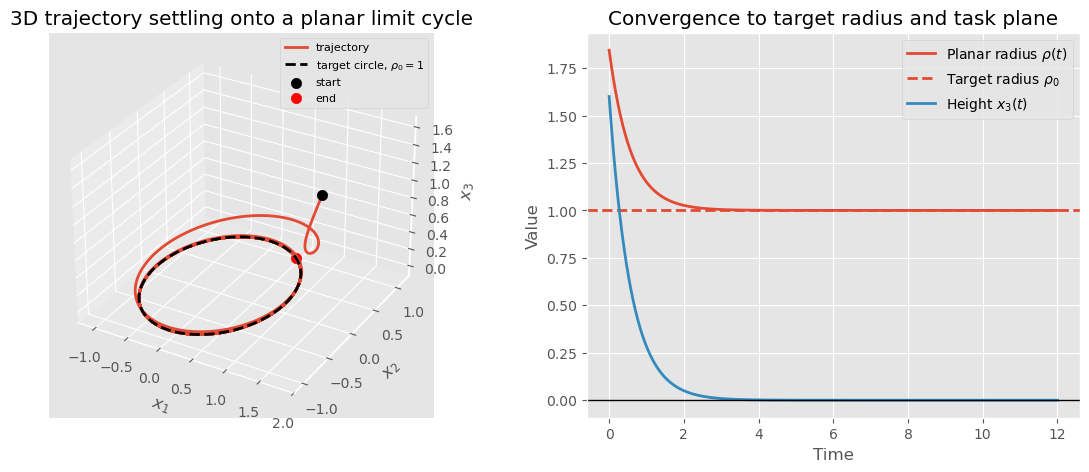

3D planar limit-cycle verification
----------------------------------
Initial planar radius rho(0)       : 1.843909
Final planar radius rho(tf)        : 1.000000
Target radius rho0                 : 1.000000
Final radius error rho(tf)-rho0    : 7.895511e-10
Initial height x3(0)               : 1.600000
Final height x3(tf)                : 1.504800e-09


In [56]:
from scipy.integrate import solve_ivp
import numpy as np
import matplotlib.pyplot as plt


def paper_3d_rhs(t, x, rho0=1.0, M=3.0, R=4.0):
    """
    Simplified 3D extension of the paper-inspired DS.

    x1-x2 plane:
        rho_dot   = -sqrt(M)*(rho-rho0)
        theta_dot = R*exp(-M^2*(rho-rho0)^2)

    x3 direction:
        x3_dot = -sqrt(M)*x3
    """
    x1, x2, x3 = x
    sqrt_M = np.sqrt(M)

    rho_xy = np.hypot(x1, x2)

    if rho_xy < 1e-10:
        e_r = np.array([1.0, 0.0])
    else:
        e_r = np.array([x1, x2]) / rho_xy

    e_theta = np.array([-e_r[1], e_r[0]])

    rho_dot = -sqrt_M * (rho_xy - rho0)
    theta_dot = R * np.exp(-(M**2) * (rho_xy - rho0)**2)

    xy_dot = rho_dot * e_r + rho_xy * theta_dot * e_theta
    x3_dot = -sqrt_M * x3

    return [xy_dot[0], xy_dot[1], x3_dot]


# Parameters
rho0 = 1.0
M = 3.0
R = 4.0

x0 = np.array([1.8, -0.4, 1.6])
t_end = 12.0
t_eval = np.linspace(0, t_end, 2500)

sol = solve_ivp(
    lambda t, x: paper_3d_rhs(t, x, rho0=rho0, M=M, R=R),
    [0, t_end],
    x0,
    t_eval=t_eval,
    rtol=1e-10,
    atol=1e-12
)

t = sol.t
xs3 = sol.y.T

rho_xy = np.linalg.norm(xs3[:, :2], axis=1)
x3_error = xs3[:, 2]

# Target circle in the plane x3 = 0
theta_grid = np.linspace(0, 2*np.pi, 400)
circle_x = rho0 * np.cos(theta_grid)
circle_y = rho0 * np.sin(theta_grid)
circle_z = np.zeros_like(theta_grid)


fig = plt.figure(figsize=(14, 5))

# ------------------------------------------------------------
# 1) 3D trajectory
# ------------------------------------------------------------
ax = fig.add_subplot(1, 2, 1, projection="3d")

ax.plot(xs3[:, 0], xs3[:, 1], xs3[:, 2], lw=2, label="trajectory")
ax.plot(circle_x, circle_y, circle_z, "k--", lw=2, label=r"target circle, $\rho_0=1$")

ax.scatter(xs3[0, 0], xs3[0, 1], xs3[0, 2],
           c="black", s=55, label="start")
ax.scatter(xs3[-1, 0], xs3[-1, 1], xs3[-1, 2],
           c="red", s=55, label="end")

ax.set_title("3D trajectory settling onto a planar limit cycle")
ax.set_xlabel(r"$x_1$")
ax.set_ylabel(r"$x_2$")
ax.set_zlabel(r"$x_3$")
ax.legend(fontsize=8)

# ------------------------------------------------------------
# 2) Radius and plane convergence
# ------------------------------------------------------------
ax2 = fig.add_subplot(1, 2, 2)

ax2.plot(t, rho_xy, lw=2, label=r"Planar radius $\rho(t)$")
ax2.axhline(rho0, ls="--", lw=2, label=r"Target radius $\rho_0$")
ax2.plot(t, x3_error, lw=2, label=r"Height $x_3(t)$")
ax2.axhline(0.0, color="black", lw=1)

ax2.set_title("Convergence to target radius and task plane")
ax2.set_xlabel("Time")
ax2.set_ylabel("Value")
ax2.legend()
ax2.grid(True)

plt.show()


print("3D planar limit-cycle verification")
print("----------------------------------")
print(f"Initial planar radius rho(0)       : {rho_xy[0]:.6f}")
print(f"Final planar radius rho(tf)        : {rho_xy[-1]:.6f}")
print(f"Target radius rho0                 : {rho0:.6f}")
print(f"Final radius error rho(tf)-rho0    : {rho_xy[-1] - rho0:.6e}")
print(f"Initial height x3(0)               : {x3_error[0]:.6f}")
print(f"Final height x3(tf)                : {x3_error[-1]:.6e}")

**Observation:**  
The 3D simulation shows that the trajectory does not directly converge to a point. Instead, the vertical component $x_3$ decays toward zero, so the motion gradually settles onto the plane $x_3=0$. Once the trajectory is close to this plane, the radial dynamics in the $x_1$-$x_2$ plane drive the motion toward the circular orbit of radius $\rho_0=1$.

Thus, the 3D system combines two effects: the elevation dynamics attract the trajectory to a plane, while the planar radial dynamics attract it to a limit cycle. This demonstrates how the 2D point-attractor/limit-cycle idea can be extended to a spatial robot-motion setting, where the robot end-effector can first approach a task plane and then execute a rhythmic motion on that plane.

## 11. MuJoCo Simulation of the Proposed Dynamical System on Franka Research 3 Robot

## 12. Conclusion

Khadivar, Lauzana, and Billard propose a Hopf-inspired dynamical-system framework that unifies point-to-point and rhythmic robot motions. By changing a small number of interpretable parameters, the same system can move between a stable equilibrium and a stable limit cycle. The simulations in this notebook reproduce the central mechanism, analyze its stability, visualize its bifurcation-like parameter sweep, compare smooth parameter modulation against hard switching, and show a small parameter-learning experiment from synthetic demonstration data.